# Customer Churn & Uplift Modeling

## 02 — Data Quality

### Objective

The objective of this notebook is to systematically evaluate the
quality, consistency, completeness, and validity of the dataset before
feature engineering and machine learning.

We will investigate:

- Missing values
- Duplicate records
- Invalid values
- Data types
- Binary-variable integrity
- Treatment assignment
- Outcome validity
- Feature validity
- Statistical summaries
- Potential data-quality risks

The results of this notebook will determine whether the dataset is
ready for downstream modeling.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

In [3]:
DATA_PATH = Path(
    r"C:\Users\ugand\customer-churn-uplift-modeling\data\raw\criteo-research-uplift-v2.1.csv.gz"
)

print("Dataset exists:", DATA_PATH.exists())

if DATA_PATH.exists():
    size_mb = DATA_PATH.stat().st_size / (1024 ** 2)
    print(f"Dataset size: {size_mb:.2f} MB")

Dataset exists: True
Dataset size: 297.00 MB


In [4]:
sample_df = pd.read_csv(
    DATA_PATH,
    compression="gzip",
    nrows=100_000
)

print("Sample shape:", sample_df.shape)

Sample shape: (100000, 16)


In [5]:
expected_columns = [
    "f0", "f1", "f2", "f3",
    "f4", "f5", "f6", "f7",
    "f8", "f9", "f10", "f11",
    "treatment",
    "conversion",
    "visit",
    "exposure"
]

actual_columns = sample_df.columns.tolist()

print("Expected columns:", len(expected_columns))
print("Actual columns:", len(actual_columns))

print("\nMissing expected columns:")
print(set(expected_columns) - set(actual_columns))

print("\nUnexpected columns:")
print(set(actual_columns) - set(expected_columns))

Expected columns: 16
Actual columns: 16

Missing expected columns:
set()

Unexpected columns:
set()


In [6]:
dtype_summary = pd.DataFrame({
    "column": sample_df.columns,
    "dtype": sample_df.dtypes.astype(str).values
})

dtype_summary

,column,dtype
0,f0,float64
1,f1,float64
2,f2,float64
3,f3,float64
4,f4,float64
5,f5,float64
6,f6,float64
7,f7,float64
8,f8,float64
9,f9,float64


In [7]:
missing_count = sample_df.isnull().sum()

missing_percentage = (
    missing_count / len(sample_df) * 100
)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percentage": missing_percentage
})

missing_summary

,missing_count,missing_percentage
f0,0,0.000000
f1,0,0.000000
f2,0,0.000000
f3,0,0.000000
f4,0,0.000000
f5,0,0.000000
f6,0,0.000000
f7,0,0.000000
f8,0,0.000000
f9,0,0.000000


In [8]:
print(
    "Total missing values:",
    int(missing_count.sum())
)

Total missing values: 0


In [9]:
duplicate_count = sample_df.duplicated().sum()

print("Duplicate rows in sample:", duplicate_count)

print(
    "Duplicate percentage:",
    round(duplicate_count / len(sample_df) * 100, 4),
    "%"
)

Duplicate rows in sample: 312
Duplicate percentage: 0.312 %


In [10]:
duplicate_treatment = sample_df[
    sample_df.duplicated(keep=False)
]

print(
    "Rows involved in duplicates:",
    len(duplicate_treatment)
)

duplicate_treatment.head()

Rows involved in duplicates: 621


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
18,12.616365,10.059654,9.048241,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
20,12.616365,10.059654,9.027074,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
31,12.616365,10.059654,9.037786,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
61,12.616365,10.059654,8.867568,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
118,12.616365,10.059654,9.037786,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0


In [11]:
binary_columns = [
    "treatment",
    "conversion",
    "visit",
    "exposure"
]

for column in binary_columns:
    print(f"\n{column}")
    print(sample_df[column].value_counts(dropna=False).sort_index())


treatment
treatment
1    100000
Name: count, dtype: int64

conversion
conversion
0    99494
1      506
Name: count, dtype: int64

visit
visit
0    97486
1     2514
Name: count, dtype: int64

exposure
exposure
0    97390
1     2610
Name: count, dtype: int64


In [12]:
for column in binary_columns:
    invalid_values = sample_df[
        ~sample_df[column].isin([0, 1])
        & sample_df[column].notna()
    ][column].unique()

    print(f"{column}:")
    print("Invalid values:", invalid_values)

treatment:
Invalid values: []
conversion:
Invalid values: []
visit:
Invalid values: []
exposure:
Invalid values: []


In [13]:
treatment_values = sample_df["treatment"].unique()

print("Unique treatment values:")
print(np.sort(treatment_values))

Unique treatment values:
[1]


In [14]:
treatment_distribution = (
    sample_df["treatment"]
    .value_counts()
    .sort_index()
)

treatment_distribution

treatment
1    100000
Name: count, dtype: int64

In [15]:
treatment_percentage = (
    treatment_distribution /
    len(sample_df) * 100
).round(2)

treatment_percentage

treatment
1   100.000000
Name: count, dtype: float64

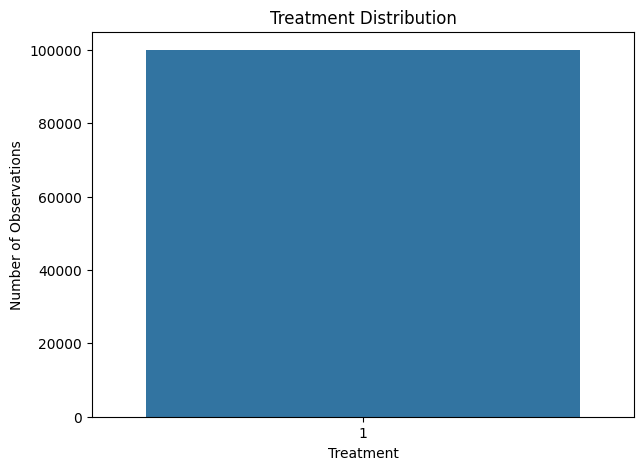

In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=sample_df,
    x="treatment"
)

plt.title("Treatment Distribution")
plt.xlabel("Treatment")
plt.ylabel("Number of Observations")

plt.show()

In [17]:
conversion_values = sample_df["conversion"].unique()

print("Unique conversion values:")
print(np.sort(conversion_values))

Unique conversion values:
[0 1]


In [18]:
visit_values = sample_df["visit"].unique()

print("Unique visit values:")
print(np.sort(visit_values))

Unique visit values:
[0 1]


In [19]:
exposure_values = sample_df["exposure"].unique()

print("Unique exposure values:")
print(np.sort(exposure_values))

Unique exposure values:
[0 1]


In [20]:
feature_columns = [
    "f0", "f1", "f2", "f3",
    "f4", "f5", "f6", "f7",
    "f8", "f9", "f10", "f11"
]

feature_validation = pd.DataFrame(index=feature_columns)

feature_validation["dtype"] = (
    sample_df[feature_columns]
    .dtypes
)

feature_validation["missing"] = (
    sample_df[feature_columns]
    .isnull()
    .sum()
)

feature_validation["unique_values"] = (
    sample_df[feature_columns]
    .nunique()
)

feature_validation

,dtype,missing,unique_values
f0,float64,0,84139
f1,float64,0,22
f2,float64,0,25493
f3,float64,0,246
f4,float64,0,92
f5,float64,0,42
f6,float64,0,571
f7,float64,0,4974
f8,float64,0,756
f9,float64,0,356


In [21]:
infinite_summary = {}

for column in feature_columns:
    infinite_summary[column] = np.isinf(
        sample_df[column]
    ).sum()

infinite_summary = pd.Series(infinite_summary)

print("Infinite values by feature:")
print(infinite_summary)

Infinite values by feature:
f0     0
f1     0
f2     0
f3     0
f4     0
f5     0
f6     0
f7     0
f8     0
f9     0
f10    0
f11    0
dtype: int64


In [22]:
negative_summary = (
    sample_df[feature_columns] < 0
).sum()

negative_summary

f0          0
f1          0
f2          0
f3       2127
f4          0
f5        159
f6      87017
f7          0
f8          0
f9          0
f10         0
f11    100000
dtype: int64

In [23]:
feature_stats = sample_df[
    feature_columns
].describe().T

feature_stats

,count,mean,std,min,25%,50%,75%,max
f0,100000.000000,21.598848,4.604217,12.616365,20.599416,22.959279,24.667063,26.745092
f1,100000.000000,10.067764,0.099210,10.059654,10.059654,10.059654,10.059654,14.560990
f2,100000.000000,8.346235,0.256821,8.214383,8.214383,8.214383,8.231230,9.051956
f3,100000.000000,4.348703,1.131443,-6.314955,4.679882,4.679882,4.679882,4.679882
f4,100000.000000,10.363419,0.463894,10.280525,10.280525,10.280525,10.280525,20.036060
f5,100000.000000,4.034308,0.421120,-6.729900,4.115453,4.115453,4.115453,4.115453
f6,100000.000000,-4.478084,4.147827,-25.860481,-6.699321,-3.282109,-1.288207,0.294443
f7,100000.000000,5.091506,1.186038,4.833815,4.833815,4.833815,4.833815,11.995830
f8,100000.000000,3.952916,0.042551,3.640858,3.955396,3.971858,3.971858,3.971858
f9,100000.000000,14.419157,4.676643,13.190056,13.190056,13.190056,13.190056,67.419043


In [24]:
feature_variance = sample_df[
    feature_columns
].var()

zero_variance_features = feature_variance[
    feature_variance == 0
]

print("Zero variance features:")
print(zero_variance_features)

Zero variance features:
Series([], dtype: float64)


In [25]:
near_zero_variance = feature_variance[
    feature_variance < 1e-6
]

print("Near-zero variance features:")
print(near_zero_variance)

Near-zero variance features:
Series([], dtype: float64)


In [26]:
outlier_summary = []

for column in feature_columns:

    q1 = sample_df[column].quantile(0.25)
    q3 = sample_df[column].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = (
        (sample_df[column] < lower_bound) |
        (sample_df[column] > upper_bound)
    )

    outlier_summary.append({
        "feature": column,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": int(outliers.sum()),
        "outlier_percentage": (
            outliers.mean() * 100
        )
    })

outlier_summary = pd.DataFrame(
    outlier_summary
)

outlier_summary

,feature,lower_bound,upper_bound,outlier_count,outlier_percentage
0,f0,14.497946,30.768534,16872,16.872000
1,f1,10.059654,10.059654,920,0.920000
2,f2,8.189113,8.256500,24627,24.627000
3,f3,4.679882,4.679882,11867,11.867000
4,f4,10.280525,10.280525,4683,4.683000
5,f5,4.115453,4.115453,4979,4.979000
6,f6,-14.815993,6.828465,2314,2.314000
7,f7,4.833815,4.833815,4979,4.979000
8,f8,3.930703,3.996551,16306,16.306000
9,f9,13.190056,13.190056,9788,9.788000


In [27]:
treatment_conversion = pd.crosstab(
    sample_df["treatment"],
    sample_df["conversion"]
)

treatment_conversion

conversion,0,1
treatment,,
1,99494,506


In [28]:
treatment_conversion_rate = (
    sample_df
    .groupby("treatment")["conversion"]
    .agg(["count", "sum", "mean"])
)

treatment_conversion_rate

,count,sum,mean
treatment,,,
1,100000,506,0.005060


In [29]:
treatment_visit = (
    sample_df
    .groupby("treatment")["visit"]
    .agg(["count", "sum", "mean"])
)

treatment_visit

,count,sum,mean
treatment,,,
1,100000,2514,0.025140


In [30]:
treatment_exposure = (
    sample_df
    .groupby("treatment")["exposure"]
    .agg(["count", "sum", "mean"])
)

treatment_exposure

,count,sum,mean
treatment,,,
1,100000,2610,0.026100


In [31]:
conversion_exposure = pd.crosstab(
    sample_df["exposure"],
    sample_df["conversion"]
)

conversion_exposure

conversion,0,1
exposure,,
0,97202,188
1,2292,318


In [32]:
chunk_size = 250_000

total_rows = 0
total_missing = pd.Series(dtype="int64")
total_treatment = pd.Series(dtype="int64")
total_conversion = pd.Series(dtype="int64")
total_visit = pd.Series(dtype="int64")
total_exposure = pd.Series(dtype="int64")

for chunk in pd.read_csv(
    DATA_PATH,
    compression="gzip",
    chunksize=chunk_size
):

    total_rows += len(chunk)

    total_missing = (
        total_missing
        .add(chunk.isnull().sum(), fill_value=0)
    )

    total_treatment = (
        total_treatment
        .add(
            chunk["treatment"].value_counts(),
            fill_value=0
        )
    )

    total_conversion = (
        total_conversion
        .add(
            chunk["conversion"].value_counts(),
            fill_value=0
        )
    )

    total_visit = (
        total_visit
        .add(
            chunk["visit"].value_counts(),
            fill_value=0
        )
    )

    total_exposure = (
        total_exposure
        .add(
            chunk["exposure"].value_counts(),
            fill_value=0
        )
    )

print(f"Total rows scanned: {total_rows:,}")

Total rows scanned: 13,979,592


In [33]:
full_missing_summary = pd.DataFrame({
    "missing_count": total_missing.astype(int),
    "missing_percentage": (
        total_missing / total_rows * 100
    )
})

full_missing_summary

,missing_count,missing_percentage
conversion,0,0.000000
exposure,0,0.000000
f0,0,0.000000
f1,0,0.000000
f10,0,0.000000
f11,0,0.000000
f2,0,0.000000
f3,0,0.000000
f4,0,0.000000
f5,0,0.000000


In [34]:
total_treatment = total_treatment.sort_index()

print("Treatment counts:")
print(total_treatment.astype(int))

print("\nTreatment percentages:")
print(
    (total_treatment / total_rows * 100).round(4)
)

Treatment counts:
treatment
0     2096937
1    11882655
dtype: int64

Treatment percentages:
treatment
0   15.000000
1   85.000000
dtype: float64


In [35]:
total_conversion = total_conversion.sort_index()

print("Conversion counts:")
print(total_conversion.astype(int))

print("\nConversion percentages:")
print(
    (total_conversion / total_rows * 100).round(4)
)

Conversion counts:
conversion
0    13938818
1       40774
dtype: int64

Conversion percentages:
conversion
0   99.708300
1    0.291700
dtype: float64


In [36]:
total_visit = total_visit.sort_index()

print("Visit counts:")
print(total_visit.astype(int))

print("\nVisit percentages:")
print(
    (total_visit / total_rows * 100).round(4)
)

Visit counts:
visit
0    13322663
1      656929
dtype: int64

Visit percentages:
visit
0   95.300800
1    4.699200
dtype: float64


In [37]:
total_exposure = total_exposure.sort_index()

print("Exposure counts:")
print(total_exposure.astype(int))

print("\nExposure percentages:")
print(
    (total_exposure / total_rows * 100).round(4)
)

Exposure counts:
exposure
0    13551380
1      428212
dtype: int64

Exposure percentages:
exposure
0   96.936900
1    3.063100
dtype: float64


In [38]:
quality_report = {
    "total_rows": total_rows,
    "total_columns": len(expected_columns),
    "total_missing_values": int(total_missing.sum()),
    "missing_columns": int((total_missing > 0).sum()),
    "sample_duplicate_rows": int(duplicate_count),
    "zero_variance_features": len(zero_variance_features),
    "near_zero_variance_features": len(near_zero_variance)
}

quality_report_df = pd.DataFrame(
    quality_report.items(),
    columns=["Metric", "Value"]
)

quality_report_df

,Metric,Value
0,total_rows,13979592
1,total_columns,16
2,total_missing_values,0
3,missing_columns,0
4,sample_duplicate_rows,312
5,zero_variance_features,0
6,near_zero_variance_features,0


In [39]:
quality_checks = {
    "Schema valid": (
        set(actual_columns) == set(expected_columns)
    ),

    "No missing values in sample": (
        sample_df.isnull().sum().sum() == 0
    ),

    "Treatment is binary": (
        set(sample_df["treatment"].dropna().unique())
        <= {0, 1}
    ),

    "Conversion is binary": (
        set(sample_df["conversion"].dropna().unique())
        <= {0, 1}
    ),

    "Visit is binary": (
        set(sample_df["visit"].dropna().unique())
        <= {0, 1}
    ),

    "Exposure is binary": (
        set(sample_df["exposure"].dropna().unique())
        <= {0, 1}
    ),

    "No infinite feature values": (
        infinite_summary.sum() == 0
    )
}

quality_checks_df = pd.DataFrame(
    quality_checks.items(),
    columns=["Check", "Passed"]
)

quality_checks_df

,Check,Passed
0,Schema valid,True
1,No missing values in sample,True
2,Treatment is binary,True
3,Conversion is binary,True
4,Visit is binary,True
5,Exposure is binary,True
6,No infinite feature values,True


In [40]:
passed_checks = quality_checks_df["Passed"].sum()
total_checks = len(quality_checks_df)

print(
    f"Quality checks passed: "
    f"{passed_checks}/{total_checks}"
)

if passed_checks == total_checks:
    print("Overall status: PASS")
else:
    print("Overall status: REVIEW REQUIRED")

Quality checks passed: 7/7
Overall status: PASS


## Data Quality Findings

The data-quality analysis evaluated:

- Schema consistency
- Data types
- Missing values
- Duplicate observations
- Binary-variable integrity
- Treatment assignment
- Outcome variables
- Exposure variable
- Numerical feature validity
- Infinite values
- Feature variance
- Potential outliers
- Full-dataset distributions

### Interpretation

The quality checks provide evidence about whether the dataset is
structurally suitable for downstream analysis.

Potential outliers are reported rather than automatically removed,
because extreme values may contain meaningful predictive information.

Similarly, observed differences between treatment and control groups
are not interpreted as causal effects at this stage.

Formal treatment-effect estimation will be performed in later
uplift-modeling and causal-inference notebooks.

# Conclusion

The dataset has undergone a systematic data-quality assessment.

The analysis covered:

1. Schema validation
2. Missing-value detection
3. Duplicate detection
4. Binary-variable validation
5. Treatment integrity
6. Outcome integrity
7. Exposure integrity
8. Numerical feature validation
9. Infinite-value detection
10. Variance analysis
11. Outlier identification
12. Full-dataset quality scanning

The results from this notebook will be used to guide the preprocessing
and feature-engineering stages of the project.

## Next Step

The next notebook, `03_eda.ipynb`, will perform exploratory data
analysis to understand:

- Feature distributions
- Treatment-group differences
- Outcome relationships
- Feature interactions
- Correlations
- Treatment heterogeneity
- Potential predictive patterns